<a href="https://colab.research.google.com/github/immmma692-boop/DSML-individual/blob/main/3_1_K_means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 1

原始数据形状: (10841, 13)
删除缺失Rating后形状: (9367, 13)
特征矩阵形状: (9367, 12)
加入对数转换后的特征矩阵形状: (9367, 12)
训练集大小: (7493, 12), 测试集大小: (1874, 12)

5折交叉验证 R² 分数: [0.17529441 0.08020081 0.09742055 0.16681601 0.15638535]
平均 R²: 0.1352
Fitting 3 folds for each of 30 candidates, totalling 90 fits

最佳参数: {'subsample': 1.0, 'reg_lambda': 0.01, 'reg_alpha': 0, 'num_leaves': 70, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
最佳交叉验证 R²: 0.1532

测试集评估结果:
RMSE: 0.4540
MAE: 0.3172
R²: 0.1640


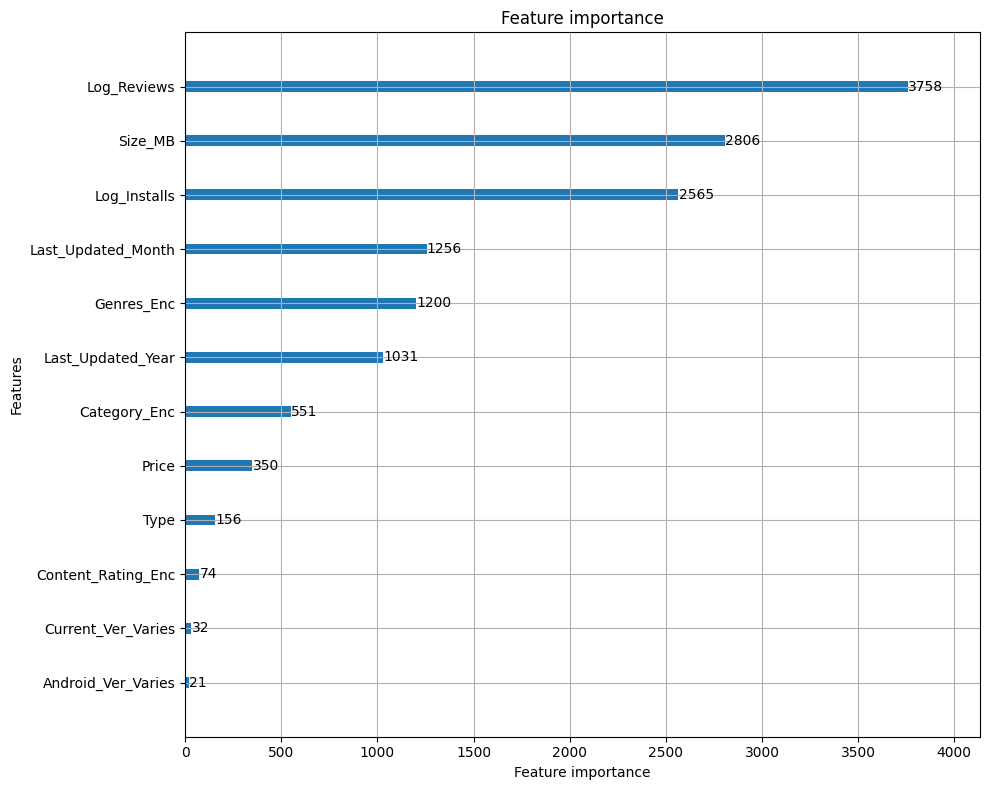


--- 训练替代方案: Random Forest (Baseline) ---
Random Forest 耗时: 3.82 秒
Random Forest RMSE: 0.4542
Random Forest R²: 0.1631


In [6]:
import pandas as pd
import numpy as np
import re
import lightgbm as lgb
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1. 加载数据
# ------------------------------
df = pd.read_excel('/content/DSML Individual Coursework Dataset2526.xlsx', sheet_name='Apps')
print("原始数据形状:", df.shape)

# ------------------------------
# 2. 数据清洗与特征工程
# ------------------------------
# 删除目标变量缺失的行
df = df.dropna(subset=['Rating']).copy()
print("删除缺失Rating后形状:", df.shape)

# 2.1 Reviews: 转为数值
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# 2.2 Size: 转换为MB数值，处理"Varies with device"
def convert_size(size_str):
    if pd.isna(size_str):
        return np.nan
    size_str = str(size_str).strip()
    if size_str == 'Varies with device':
        return np.nan
    match = re.match(r'([\d\.]+)\s*([a-zA-Z]*)', size_str)
    if match:
        num = float(match.group(1))
        unit = match.group(2).upper()
        if unit == 'M':
            return num
        elif unit == 'K':
            return num / 1024.0
        else:
            return np.nan
    return np.nan

df['Size_MB'] = df['Size'].apply(convert_size)

# 2.3 Installs: 去掉逗号和加号，转为整数
def convert_installs(inst_str):
    if pd.isna(inst_str):
        return np.nan
    inst_str = str(inst_str).replace(',', '').replace('+', '').strip()
    try:
        return int(inst_str)
    except:
        return np.nan

df['Installs'] = df['Installs'].apply(convert_installs)

# 2.4 Price: 去掉美元符号，转为浮点数
def convert_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).replace('$', '').replace(',', '').strip()
    try:
        return float(price_str)
    except:
        return np.nan

df['Price'] = df['Price'].apply(convert_price)

# 2.5 Type: 二值化
df['Type'] = df['Type'].map({'Free': 0, 'Paid': 1}).fillna(-1)

# 2.6 Content Rating: 标签编码
le_content = LabelEncoder()
df['Content_Rating_Enc'] = le_content.fit_transform(df['Content Rating'].astype(str))

# 2.7 Category: 标签编码
le_category = LabelEncoder()
df['Category_Enc'] = le_category.fit_transform(df['Category'].astype(str))

# 2.8 Genres: 取第一个类别（若有多值）并进行编码
df['First_Genre'] = df['Genres'].str.split(';').str[0].fillna('Unknown')
le_genre = LabelEncoder()
df['Genres_Enc'] = le_genre.fit_transform(df['First_Genre'])

# 2.9 Last Updated: 提取年份和月份
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
df['Last_Updated_Year'] = df['Last Updated'].dt.year.fillna(0).astype(int)
df['Last_Updated_Month'] = df['Last Updated'].dt.month.fillna(0).astype(int)

# 2.10 Current Ver & Android Ver: 是否包含"Varies with device"标志
df['Current_Ver_Varies'] = (df['Current Ver'] == 'Varies with device').astype(int)
df['Android_Ver_Varies'] = (df['Android Ver'] == 'Varies with device').astype(int)

# 2.11 选择特征列
feature_cols = [
    'Reviews', 'Size_MB', 'Installs', 'Price', 'Type',
    'Content_Rating_Enc', 'Category_Enc', 'Genres_Enc',
    'Last_Updated_Year', 'Last_Updated_Month',
    'Current_Ver_Varies', 'Android_Ver_Varies'
]
X = df[feature_cols]
y = df['Rating']

# 将经过 LabelEncoder 处理的列转换为 pandas 的 'category' 类型
# 这样 LightGBM 就会自动启动最优的类别划分算法，而不是把它们当数字比较大小
cat_features = ['Content_Rating_Enc', 'Category_Enc', 'Genres_Enc', 'Type', 'Current_Ver_Varies', 'Android_Ver_Varies']
for col in cat_features:
    X[col] = X[col].astype('category')

# 2.12 处理数值特征的缺失值（中位数填充）
num_cols = ['Reviews', 'Size_MB', 'Installs', 'Price']
imputer_num = SimpleImputer(strategy='median')
X[num_cols] = imputer_num.fit_transform(X[num_cols])

# 其他特征已用-1或编码填充，无需额外处理
print("特征矩阵形状:", X.shape)

# 2.13 处理右偏态特征：对数转换 (Log Transformation)
X['Log_Reviews'] = np.log1p(X['Reviews'])
X['Log_Installs'] = np.log1p(X['Installs'])

# 转换后，从特征矩阵中删除原始的倾斜特征，保留Log后的特征
X = X.drop(columns=['Reviews', 'Installs'])
print("加入对数转换后的特征矩阵形状:", X.shape)

# ------------------------------
# 3. 划分训练集和测试集
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

# ------------------------------
# 4. 基础 LightGBM 模型与交叉验证
# ------------------------------
base_model = lgb.LGBMRegressor(objective='regression', random_state=42,verbosity=-1)
cv_scores = cross_val_score(base_model, X_train, y_train, cv=5, scoring='r2')
print("\n5折交叉验证 R² 分数:", cv_scores)
print("平均 R²: {:.4f}".format(cv_scores.mean()))

# ------------------------------
# 5. 超参数优化（随机搜索）
# ------------------------------
param_dist = {
    'num_leaves': [31, 50, 70, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [-1, 10, 20, 30],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0, 0.01, 0.1]
}

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=30,          # 迭代次数，可依据算力调整
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\n最佳参数:", random_search.best_params_)
print("最佳交叉验证 R²: {:.4f}".format(random_search.best_score_))

# ------------------------------
# 6. 最终模型评估
# ------------------------------
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n测试集评估结果:")
print("RMSE: {:.4f}".format(rmse))
print("MAE: {:.4f}".format(mae))
print("R²: {:.4f}".format(r2))

# 可选：特征重要性
lgb.plot_importance(best_model, figsize=(10, 8))
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# ------------------------------
# 7. 替代方案对比验证 (Alternative Baseline Model)
# ------------------------------
from sklearn.ensemble import RandomForestRegressor
import time

print("\n--- 训练替代方案: Random Forest (Baseline) ---")
start_time = time.time()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time

rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest 耗时: {rf_time:.2f} 秒")
print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest R²: {rf_r2:.4f}")

# 在你的报告中，你可以将 rf_rmse 和上面 lgb 的 rmse 列表对比，
# 以此证明你选择 LightGBM 是具有科学依据的！

PHASE 1 Pro

Original data shape: (10841, 13)
Basic data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10827 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10838 non-null  object 
 4   Size            10835 non-null  object 
 5   Installs        10828 non-null  object 
 6   Type            10833 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10835 non-null  object 
 9   Genres          10831 non-null  object 
 10  Last Updated    10837 non-null  object 
 11  Current Ver     10829 non-null  object 
 12  Android Ver     10833 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None
Column names: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content 

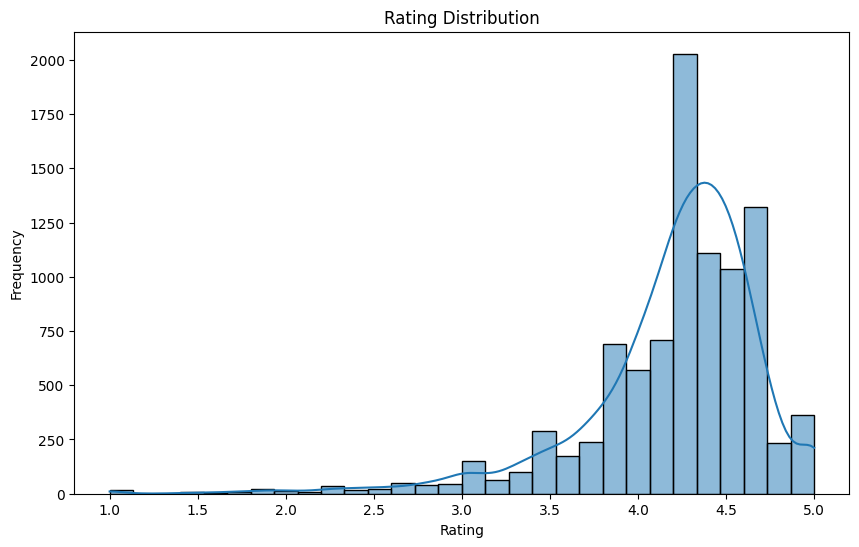

Feature matrix shape: (9366, 12)
Top 10 apps with highest number of reviews:
                                              App       Category  Rating  \
2544                                    Facebook         SOCIAL     4.1   
3943                                    Facebook         SOCIAL     4.1   
336                           WhatsApp Messenger  COMMUNICATION     4.4   
381                           WhatsApp Messenger  COMMUNICATION     4.4   
3904                          WhatsApp Messenger  COMMUNICATION     4.4   
2604                                   Instagram         SOCIAL     4.5   
2611                                   Instagram         SOCIAL     4.5   
2545                                   Instagram         SOCIAL     4.5   
3909                                   Instagram         SOCIAL     4.5   
382   Messenger â€“ Text and Video Chat for Free  COMMUNICATION     4.0   

         Reviews                Size      Installs  Type  Price  \
2544  78158306.0  Varies with

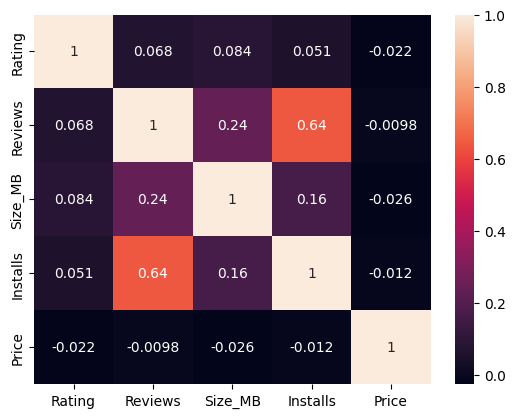

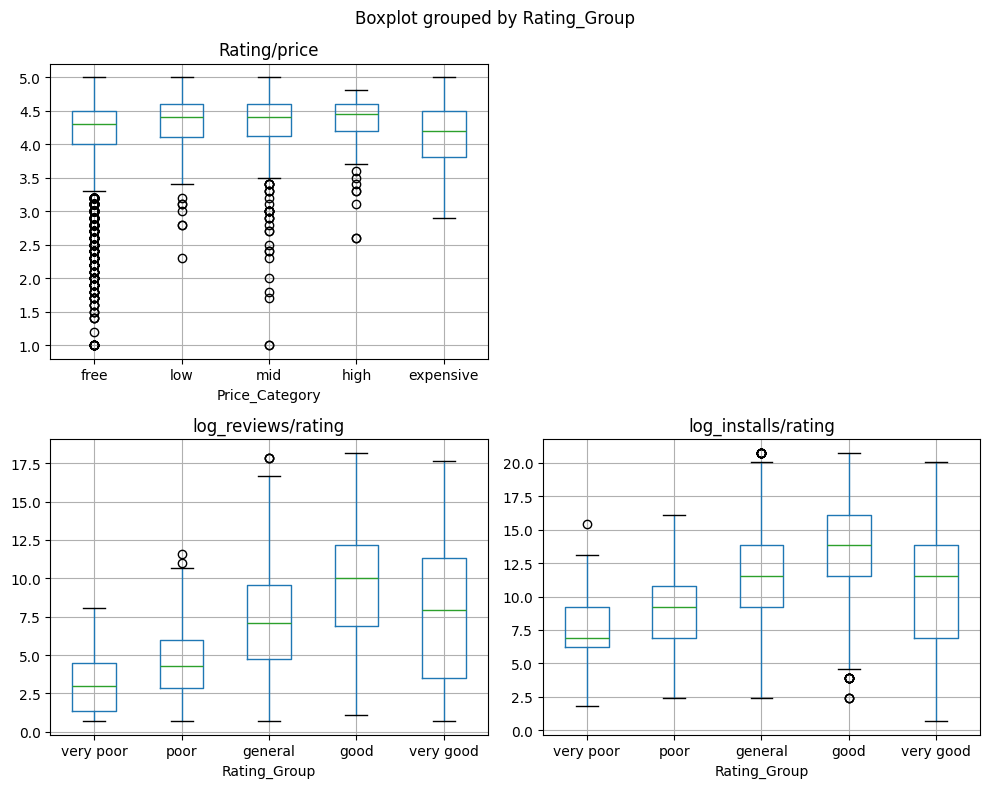

Training set size: (7492, 12), Test set size: (1874, 12)

5-fold cross-validation R² scores: [0.19424072 0.12889121 0.16841801 0.16475586 0.15627819]
Average R²: 0.1625
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best parameters: {'subsample': 1.0, 'reg_lambda': 0.01, 'reg_alpha': 0.1, 'num_leaves': 100, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best cross-validation R²: 0.1711

Test set evaluation results:
RMSE: 0.4499
MAE: 0.3092
R²: 0.1790


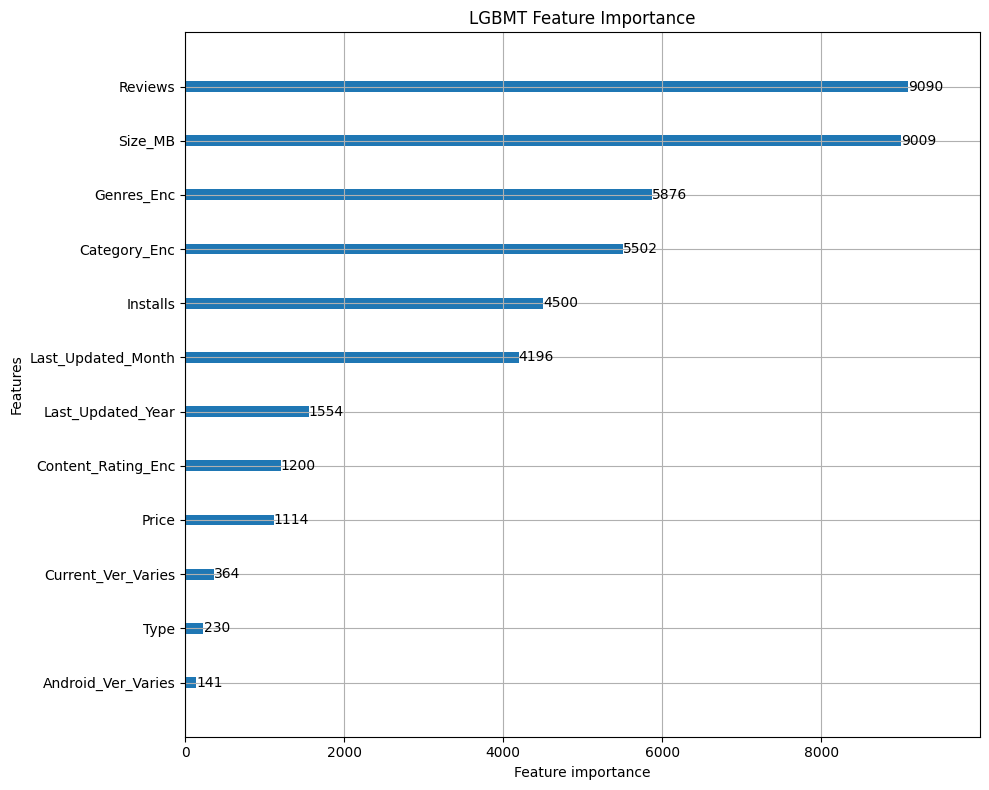


R-squared score of Random Forest using 5-fold cross-validation: [0.20871593 0.14500543 0.17752416 0.15266147 0.12934475]
Random Forest Average R²: 0.1627
Fitting 3 folds for each of 30 candidates, totalling 90 fits

optimal parameters for Random Forest: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Random Forest Best Cross-Validation R²: 0.1806

The evaluation result of the random forest test set:
RMSE: 0.4456
MAE: 0.2952
R²: 0.1946


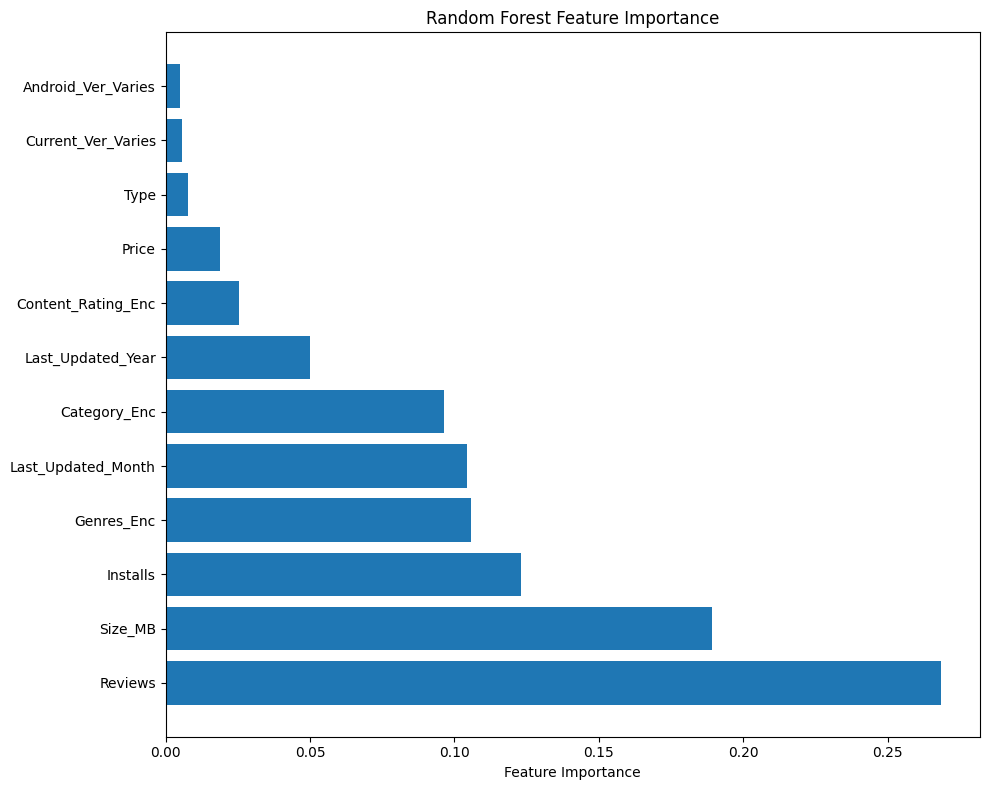

In [8]:
import pandas as pd
import numpy as np
import re
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1. Load data
# ------------------------------
df = pd.read_excel('/content/DSML Individual Coursework Dataset2526.xlsx', sheet_name='Apps')
print("Original data shape:", df.shape)
print("Basic data information:")
print(df.info())

print("Column names:", df.columns.tolist())
print("First 5 rows:\n", df.head())

print("Missing values:\n", df.isnull().sum())
print("\nTarget variable (Rating) distribution:")
print("Descriptive statistics of target variable Rating:\n", df['Rating'].describe())
print(df['Rating'].describe())


# ------------------------------
# 2. Data cleaning and feature engineering
# ------------------------------
# 2.1  Remove rows with missing target variable
df = df.dropna(subset=['Rating']).copy()
# Remove rows with Rating greater than 5
df=df[df['Rating']<= 5]
print("Shape after dropping missing Rating:", df.shape)

# Visualize target variable distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'].dropna(), bins=30, kde=True)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# 2.2 Reviews: convert to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# 2.3 Size: convert to MB numeric, handle "Varies with device"
def convert_size(size_str):
    if pd.isna(size_str):
        return np.nan
    size_str = str(size_str).strip()
    if size_str == 'Varies with device':
        return np.nan
    match = re.match(r'([\d\.]+)\s*([a-zA-Z]*)', size_str)
    if match:
        num = float(match.group(1))
        unit = match.group(2).upper()
        if unit == 'M':
            return num
        elif unit == 'K':
            return num / 1024.0
        else:
            return np.nan
    return np.nan

df['Size_MB'] = df['Size'].apply(convert_size)

# 2.4 Installs: remove commas and plus signs, convert to integer
def convert_installs(inst_str):
    if pd.isna(inst_str):
        return np.nan
    inst_str = str(inst_str).replace(',', '').replace('+', '').strip()
    try:
        return int(inst_str)
    except:
        return np.nan

df['Installs'] = df['Installs'].apply(convert_installs)

# 2.5 Price: remove dollar sign, convert to float
def convert_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).replace('$', '').replace(',', '').strip()
    try:
        return float(price_str)
    except:
        return np.nan

df['Price'] = df['Price'].apply(convert_price)

# 2.6 Type: binarize
df['Type'] = df['Type'].map({'Free': 0, 'Paid': 1}).fillna(-1)

# 2.7 Content Rating: label encoding
le_content = LabelEncoder()
df['Content_Rating_Enc'] = le_content.fit_transform(df['Content Rating'].astype(str))

# 2.8 Category: label encoding
le_category = LabelEncoder()
df['Category_Enc'] = le_category.fit_transform(df['Category'].astype(str))

# 2.9 Genres: take first category (if multiple) and encode
df['First_Genre'] = df['Genres'].str.split(';').str[0].fillna('Unknown')
le_genre = LabelEncoder()
df['Genres_Enc'] = le_genre.fit_transform(df['First_Genre'])

# 2.10 Last Updated: extract year and month
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
df['Last_Updated_Year'] = df['Last Updated'].dt.year.fillna(0).astype(int)
df['Last_Updated_Month'] = df['Last Updated'].dt.month.fillna(0).astype(int)

# 2.11 Current Ver & Android Ver: flag for "Varies with device"
df['Current_Ver_Varies'] = (df['Current Ver'] == 'Varies with device').astype(int)
df['Android_Ver_Varies'] = (df['Android Ver'] == 'Varies with device').astype(int)

# 2.12 Select feature columns
feature_cols = [
    'Reviews', 'Size_MB', 'Installs', 'Price', 'Type',
    'Content_Rating_Enc', 'Category_Enc', 'Genres_Enc',
    'Last_Updated_Year', 'Last_Updated_Month',
    'Current_Ver_Varies', 'Android_Ver_Varies'
]
X = df[feature_cols]
y = df['Rating']

# 2.13 Handle missing values in numerical features (median imputation)
num_cols = ['Reviews', 'Size_MB', 'Installs', 'Price']
imputer_num = SimpleImputer(strategy='median')
X[num_cols] = imputer_num.fit_transform(X[num_cols])

# Other features already filled with -1 or encoded, no further processing needed
print("Feature matrix shape:", X.shape)

# ------------------------------------------
# 3. Data analysis after feature engineering
# ------------------------------------------
# 3.1 Correlation heatmap of numerical features. There is some correlation between installs and reviews; generally, apps with high installs also have many reviews.
features_original = ['Rating','Reviews', 'Size_MB', 'Installs', 'Price']
corr_pearson_original = df[features_original].corr(method='pearson')
sns.heatmap(corr_pearson_original, annot=True)

# 3.2 Top 10 apps with highest number of reviews
salesDf=df.sort_values(by='Reviews', ascending=False)
print("Top 10 apps with highest number of reviews:\n", salesDf.head(10))
# Top 10 apps with highest number of installs
salesDf=df.sort_values(by='Installs',ascending=False)
print("Top 10 apps with highest installs:\n", salesDf.head(10))


# 3.3 Which categories have the most apps in the market?
querySer=df.groupby(['Genres']).size()
print("Categories with the most apps in the market:\n", querySer.sort_values(ascending=False))


#3.4 price of  apps influnes
# paid apps situation
fufei=df[features_original].loc[:,'Price']>0
paid=df[features_original].loc[fufei,:]
print("Average price of paid apps:\n", paid.describe())

# Free apps situation
mianfei=df[features_original].loc[:,'Price']<=0
free=df[features_original].loc[mianfei,:]
print("Free apps situation:\n", free.describe())

# What proportion of apps are paid?
querySer=df.groupby(['Type']).size()
print("Proportion of paid apps in total apps:\n", querySer)

#3.5 Boxplot analysis

fig5, axes = plt.subplots(2, 2, figsize=(10, 8))

# Rating boxplot (by price category)
df['Price_Category'] = pd.cut(df['Price'],
                                    bins=[-0.1, 0, 1, 5, 10, float('inf')],
                                    labels=['free', 'low', 'mid', 'high', 'expensive'])

df.boxplot(column='Rating', by='Price_Category', ax=axes[0, 0])
axes[0, 0].set_title('Rating/price')
axes[0, 1].set_visible(False)

# Reviews boxplot (by rating interval)
df['Rating_Group'] = pd.cut(df['Rating'],
                                  bins=[0, 2, 3, 4, 4.5, 5],
                                  labels=['very poor', 'poor', 'general', 'good', 'very good'])

# Take log of Reviews and draw boxplot
df['Log_Reviews'] = np.log1p(df['Reviews'])
log_reviews_by_rating = df[['Log_Reviews', 'Rating_Group']].dropna()
log_reviews_by_rating.boxplot(column='Log_Reviews', by='Rating_Group', ax=axes[1, 0])
axes[1, 0].set_title('log_reviews/rating')

# Installs boxplot (by rating interval)
df['Log_Installs'] = np.log1p(df['Installs'])
log_installs_by_rating = df[['Log_Installs', 'Rating_Group']].dropna()
log_installs_by_rating.boxplot(column='Log_Installs', by='Rating_Group', ax=axes[1, 1])
axes[1, 1].set_title('log_installs/rating')

plt.tight_layout()
plt.show()

# ------------------------------
# 4. Split training and test sets
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")


# ------------------------------
# 5. Basic LightGBM model and cross-validation
# ------------------------------
base_model = lgb.LGBMRegressor(objective='regression', random_state=42,verbosity=-1)
cv_scores = cross_val_score(base_model, X_train, y_train, cv=5, scoring='r2')
print("\n5-fold cross-validation R² scores:", cv_scores)
print("Average R²: {:.4f}".format(cv_scores.mean()))

# ------------------------------
# 6. Hyperparameter optimization (random search)
# ------------------------------
param_dist = {
    'num_leaves': [31, 50, 70, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [-1, 10, 20, 30],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0, 0.01, 0.1]
}

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=30,          # number of iterations, can be adjusted based on computational power
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nBest parameters:", random_search.best_params_)
print("Best cross-validation R²: {:.4f}".format(random_search.best_score_))

# ------------------------------
# 7. Final model evaluation
# ------------------------------
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nTest set evaluation results:")
print("RMSE: {:.4f}".format(rmse))
print("MAE: {:.4f}".format(mae))
print("R²: {:.4f}".format(r2))

# Optional: feature importance
lgb.plot_importance(best_model, figsize=(10, 8))
plt.title('LGBMT Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()


# ------------------------------
# 8. Random Forest Model: Cross-Validation, Hyperparameter Optimization, and Evaluation
# ------------------------------

# 8.1 Basic Random Forest Model with Cross-Validation
base_rf = RandomForestRegressor(random_state=42)
rf_cv_scores = cross_val_score(base_rf, X_train, y_train, cv=5, scoring='r2')
print("\nR-squared score of Random Forest using 5-fold cross-validation:", rf_cv_scores)
print("Random Forest Average R²: {:.4f}".format(rf_cv_scores.mean()))

# 8.2 Hyperparameter Optimization of Random Forest (Random Search)
rf_param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf_random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=rf_param_dist,
    n_iter=30,                # The number of iterations can be adjusted according to computing power
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print("\noptimal parameters for Random Forest:", rf_random_search.best_params_)
print("Random Forest Best Cross-Validation R²: {:.4f}".format(rf_random_search.best_score_))

# 8.3 Final Random Forest Model Evaluation
best_rf = rf_random_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nThe evaluation result of the random forest test set:")
print("RMSE: {:.4f}".format(rmse_rf))
print("MAE: {:.4f}".format(mae_rf))
print("R²: {:.4f}".format(r2_rf))

# 8.4 Random Forest Feature Importance Visualization
feature_importance_rf = best_rf.feature_importances_
feature_names = X.columns  # 特征列名

plt.figure(figsize=(10, 8))
indices = np.argsort(feature_importance_rf)[::-1]
plt.barh(range(len(indices)), feature_importance_rf[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('rf_feature_importance.png')
plt.show()

Phase 2 K-means

In [5]:
# Phase 2 原型: 用于App市场细分的 K-Means 聚类
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score

# 1. 特征选择与预处理
# 假设 'app_data' 是从 Phase 1 清洗好的数据框
features = ['Installs', 'Price', 'Reviews']
X = df[features].copy()

# 由于App商店数据存在极度的右偏态（例如 WhatsApp 与 独立App 的体量差异），
# 在缩放之前，对数转换 (Log transformation) 是至关重要的。
X_log = np.log1p(X)

# 使用 RobustScaler 进一步减轻极端市场异常值的影响
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

# 2. 超参数优化
# (在实践中，这里会运行一个循环来寻找最优的 K 值。本原型中我们选择 K=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Market_Segment'] = kmeans.fit_predict(X_scaled)

# 3. 市场细分可视化
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=np.log1p(df['Reviews']),
    y=np.log1p(df['Installs']),
    hue=df['Market_Segment'],
    palette='viridis',
    alpha=0.7
)
plt.title('基于用户吸引力与竞争度的App市场细分')
plt.xlabel('Log(Reviews) - 竞争度/参与度的代理指标')
plt.ylabel('Log(Installs) - 市场需求的代理指标')
plt.legend(title='集群细分')
plt.show()

# 输出聚类中心点以解释商业意义
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
# 逆向对数转换以恢复可解释的真实数值
centroids_actual = np.expm1(centroids)
print("聚类中心 (真实数值): \n", centroids_actual)

NameError: name 'df' is not defined

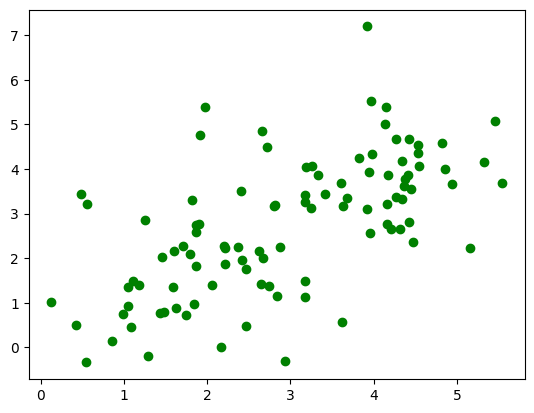

In [ ]:
# import the data generator
from sklearn.datasets import make_blobs

# create a dataset. X is a set of values to cluster; Y is the cluster they belong to
X, y = make_blobs(n_samples=100, n_features=2, centers=2)

# visualise the data in Matplotlib
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], color = 'g')
plt.show()

In [ ]:
# min-max scale the X data so it takes values between zero (min value) and one (max value)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X) # transform the data

In [ ]:
# import and fit the clustering algorithm
from sklearn.cluster import KMeans
clustering = KMeans(n_clusters=2).fit(X)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


<Axes: xlabel='x1', ylabel='x2'>

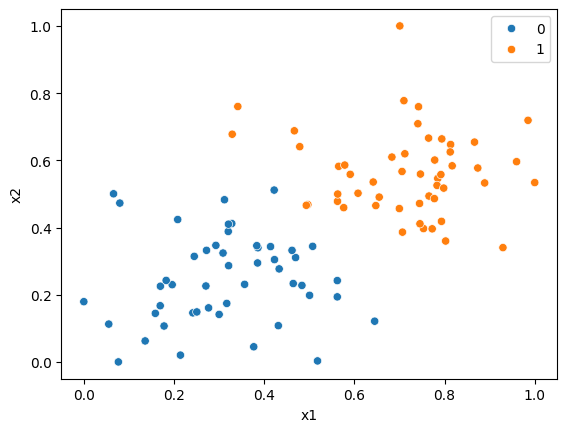

In [ ]:
# add the data and the assigned cluster labels to a Pandas dataframe
import pandas as pd
df = pd.DataFrame(data={'x1': X[:, 0], 'x2': X[:, 1], 'label': clustering.labels_})

# visualise the data using Seaborn
import seaborn as sns
sns.scatterplot(data=df, x='x1', y='x2', hue=df.label.to_list()) # note: we use the “to_list()” function to fix the labels to hue

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


<Axes: xlabel='x1', ylabel='x2'>

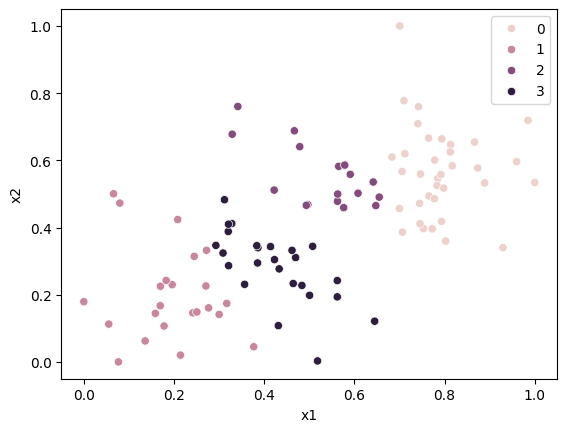

In [ ]:
# fit k-means using k=4
clustering_4 = KMeans(n_clusters=4).fit(X)
df_4 = pd.DataFrame(data={'x1': X[:, 0], 'x2': X[:, 1], 'label': clustering_4.labels_})
sns.scatterplot(data=df_4, x='x1', y='x2', hue=df_4.label.to_list())